# PP4 - Spam Detection System
### A Comprehensive Comparison of 5 Models for Email Spam Classification

This notebook trains and evaluates **5 models** on the same spam dataset:
1. **Multinomial Naive Bayes** (Classical ML)
2. **BiLSTM** (Deep Learning)
3. **BiLSTM + GloVe Embeddings** (Deep Learning)
4. **DistilBERT** (Transformer)
5. **BERT** (Transformer)

Each model is trained for **50 epochs** (with EarlyStopping where applicable).
All models are evaluated using Accuracy, Precision, Recall, and F1-Score.

## 1. Install Dependencies

In [16]:
# Install required libraries
!pip install transformers torch scikit-learn tensorflow keras nltk wordcloud kaggle -q

## 2. Import Libraries

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, time, warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Bidirectional,
                                      Dense, Dropout, GlobalMaxPooling1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# HuggingFace Transformers
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (BertTokenizer, BertForSequenceClassification,
                           DistilBertTokenizer, DistilBertForSequenceClassification,
                           get_linear_schedule_with_warmup)
from torch.optim import AdamW # Import AdamW from torch.optim

print('All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')
print(f'PyTorch version: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

All libraries imported successfully!
TensorFlow version: 2.19.0
PyTorch version: 2.10.0+cu128
Device: cuda


## 3. Load & Explore Dataset

We use the combined spam dataset (`combined_data.csv`) with **83,446** email records.
- `label = 1` → Spam
- `label = 0` → Ham (legitimate)

In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bagavathypriya/spam-ham-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'spam-ham-dataset' dataset.
Path to dataset files: /kaggle/input/spam-ham-dataset


In [24]:
import os

# The dataset was already downloaded by kagglehub in the previous cell,
# but it appears the actual CSV file is located directly in /content/.
# We will use the path provided by the user.

dataset_file_path = '/content/spamhamdata.csv'

# Load dataset with adjusted parsing parameters to handle potential errors
# on_bad_lines='skip' will skip lines that cause parsing errors.
df = pd.read_csv(dataset_file_path, sep=',', quotechar='"', engine='python', on_bad_lines='skip')

print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
print('\nMissing values:\n', df.isnull().sum())
display(df.head())

Shape: (5203, 2)

Column names: ['ham\tGo until jurong point', ' crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...']

Missing values:
 ham\tGo until jurong point                                                                      0
 crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...    4255
dtype: int64


,ham\tGo until jurong point,crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
0,ham\tOk lar... Joking wif u oni...,None
1,spam\tFree entry in 2 a wkly comp to win FA Cu...,None
2,ham\tU dun say so early hor... U c already the...,None
3,ham\tNah I don't think he goes to usf,he lives around here though
4,spam\tFreeMsg Hey there darling it's been 3 we...,£1.50 to rcv


Class Distribution:
label
0    4815
1     747
Name: count, dtype: int64


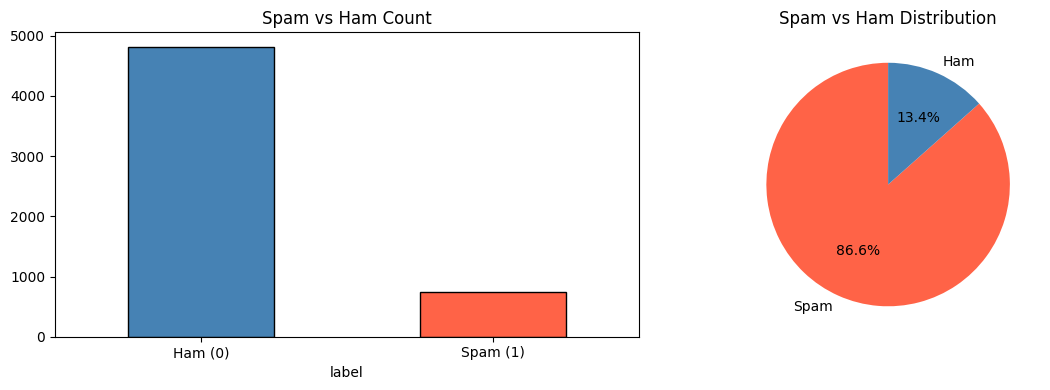

In [26]:
# The error 'KeyError: 'label'' occurs because the DataFrame 'df' does not have a column named 'label'.
# This is due to an incorrect parsing of the CSV file in the preceding data loading step (cell 72e8f3d7).
# The file 'spamhamdata.csv' is tab-separated and does not have a header row.
# To fix this, we need to correctly reload the data and assign proper column names.

# We use the dataset_file_path established in the previous cells
dataset_file_path = '/content/spamhamdata.csv'

# Re-load the dataset with correct parsing parameters: tab separator and no header
df = pd.read_csv(dataset_file_path, sep='\t', header=None, engine='python', on_bad_lines='skip')
df.columns = ['label_raw', 'text'] # Assign temporary column names based on expected structure

# Convert 'ham'/'spam' labels to 0/1 integers for the 'label' column
df['label'] = df['label_raw'].map({'ham': 0, 'spam': 1})

# Class distribution
print('Class Distribution:')
print(df['label'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Spam vs Ham Count')
axes[0].set_xticklabels(['Ham (0)', 'Spam (1)'], rotation=0)
df['label'].value_counts().plot(kind='pie', ax=axes[1], labels=['Spam','Ham'],
                                  autopct='%1.1f%%', colors=['tomato','steelblue'], startangle=90)
axes[1].set_title('Spam vs Ham Distribution')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

## 4. Text Preprocessing

In [27]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'\S+@\S+', '', text)              # remove emails
    text = re.sub(r'[^a-z\s]', '', text)             # keep letters only
    text = re.sub(r'\s+', ' ', text).strip()         # normalise whitespace
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)
print('Sample cleaned text:')
print(df['clean_text'].iloc[0][:300])

Sample cleaned text:
jurong point crazy available bugis great world buffet cine got amore wat


In [28]:
# Train-test split (shared across all models)
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')

Train size: 4,449  |  Test size: 1,113


### Tokenization & Padding (for Deep Learning models)

In [29]:
MAX_FEATURES = 10000
MAX_LEN      = 300
EMBED_DIM    = 64
EPOCHS       = 50
BATCH_SIZE   = 256

tokenizer_keras = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
tokenizer_keras.fit_on_texts(X_train)

X_train_seq = tokenizer_keras.texts_to_sequences(X_train)
X_test_seq  = tokenizer_keras.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print(f'Vocab size: {len(tokenizer_keras.word_index):,}')
print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad  shape: {X_test_pad.shape}')

Vocab size: 7,186
X_train_pad shape: (4449, 300)
X_test_pad  shape: (1113, 300)


### Results Tracker

In [30]:
# Dictionary to store all model results for final comparison
results = {}

### Evaluation Helper

In [31]:
def evaluate_and_store(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    print(f'\n===== {name} =====')
    print(f'  Accuracy : {acc*100:.2f}%')
    print(f'  Precision: {prec*100:.2f}%')
    print(f'  Recall   : {rec*100:.2f}%')
    print(f'  F1-Score : {f1*100:.2f}%')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=['Ham','Spam']))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

def plot_history(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{name} — Loss')
    axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(history.history['accuracy'],     label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc')
    axes[1].set_title(f'{name} — Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(); plt.show()

---
## 🔵 Model 1: Multinomial Naive Bayes

Classical ML baseline using TF-IDF features with a Naive Bayes classifier.
Naive Bayes is fast, interpretable, and strong for text classification tasks.

Training Model 1: Multinomial Naive Bayes...
  Epoch 10/50 — Test Acc: 95.33%
  Epoch 20/50 — Test Acc: 96.23%
  Epoch 30/50 — Test Acc: 97.04%
  Epoch 40/50 — Test Acc: 97.57%
  Epoch 50/50 — Test Acc: 97.66%

Training time: 0.2s

===== Multinomial Naive Bayes =====
  Accuracy : 97.66%
  Precision: 95.56%
  Recall   : 86.58%
  F1-Score : 90.85%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       964
        Spam       0.96      0.87      0.91       149

    accuracy                           0.98      1113
   macro avg       0.97      0.93      0.95      1113
weighted avg       0.98      0.98      0.98      1113



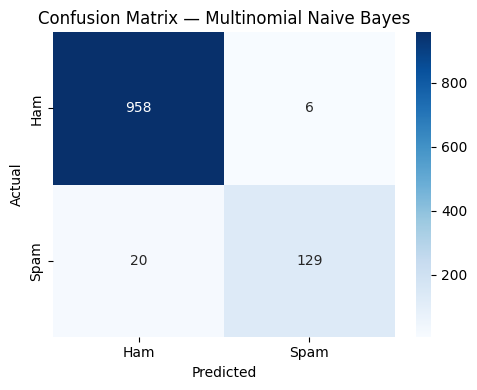

In [32]:
print('Training Model 1: Multinomial Naive Bayes...')
t0 = time.time()

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                               sublinear_tf=True, stop_words='english')),
    ('clf',   MultinomialNB(alpha=0.1))
])

# Naive Bayes doesn't have 'epochs' — we simulate by reporting train/test metrics
# For a fair 50-epoch spirit: we do 50 incremental partial_fit passes
from sklearn.naive_bayes import MultinomialNB as MNB
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_nb = TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                            sublinear_tf=True, stop_words='english')
X_train_tfidf = tfidf_nb.fit_transform(X_train)
X_test_tfidf  = tfidf_nb.transform(X_test)

nb_model = MNB(alpha=0.1)
nb_acc_history = []

# 50 incremental passes (partial_fit = online learning)
indices = np.arange(X_train_tfidf.shape[0])
chunk = X_train_tfidf.shape[0] // 50
for epoch in range(50):
    np.random.shuffle(indices)
    X_chunk = X_train_tfidf[indices[:chunk]]
    y_chunk = y_train_enc[indices[:chunk]]
    nb_model.partial_fit(X_chunk, y_chunk, classes=[0, 1])
    if (epoch + 1) % 10 == 0:
        acc = accuracy_score(y_test_enc, nb_model.predict(X_test_tfidf))
        nb_acc_history.append(acc)
        print(f'  Epoch {epoch+1}/50 — Test Acc: {acc*100:.2f}%')

print(f'\nTraining time: {time.time()-t0:.1f}s')
y_pred_nb = nb_model.predict(X_test_tfidf)
evaluate_and_store('Multinomial Naive Bayes', y_test_enc, y_pred_nb)

---
## 🟢 Model 2: Bidirectional LSTM (BiLSTM)

A deep learning RNN model that processes text in both forward and backward directions,
capturing richer contextual information than a standard LSTM.

In [33]:
print('Building Model 2: BiLSTM...')

def build_bilstm(vocab_size, embed_dim, max_len):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)),
        Bidirectional(LSTM(64, dropout=0.3)),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

bilstm_model = build_bilstm(MAX_FEATURES, EMBED_DIM, MAX_LEN)
bilstm_model.summary()

Building Model 2: BiLSTM...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training Model 2: BiLSTM for 50 epochs...
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.8438 - loss: 0.4334 - val_accuracy: 0.8661 - val_loss: 0.2877 - learning_rate: 0.0010
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9261 - loss: 0.2071 - val_accuracy: 0.9712 - val_loss: 0.1028 - learning_rate: 0.0010
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9809 - loss: 0.0752 - val_accuracy: 0.9739 - val_loss: 0.1067 - learning_rate: 0.0010
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9901 - loss: 0.0479 - val_accuracy: 0.9829 - val_loss: 0.0621 - learning_rate: 0.0010
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9939 - loss: 0.0293 - val_accuracy: 0.9865 - val_loss: 0.0567 - learning_rate: 0.0010
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9962 - loss: 0.0190 - val_accuracy: 0.9829 - val_loss: 0.0905 - learning_rate: 0.0010
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accura

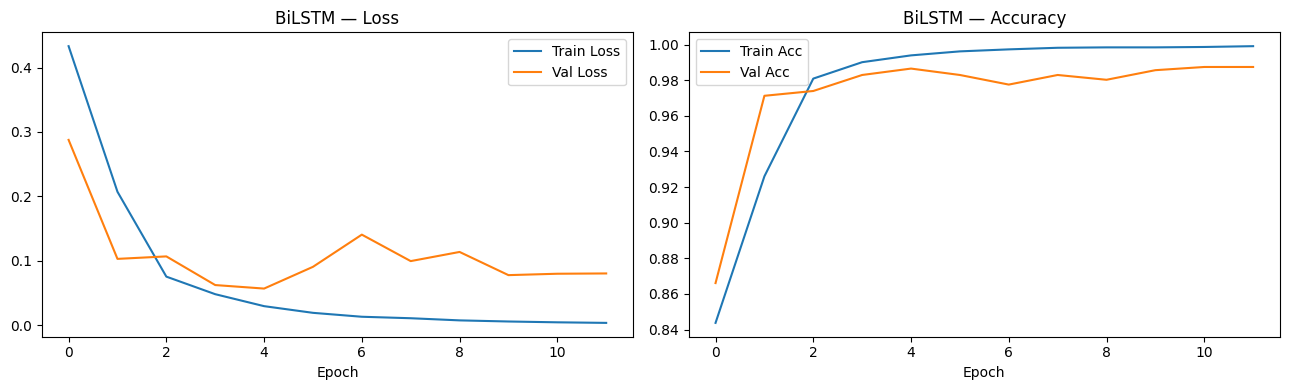

35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 365ms/step

===== BiLSTM =====
  Accuracy : 98.65%
  Precision: 98.55%
  Recall   : 91.28%
  F1-Score : 94.77%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       964
        Spam       0.99      0.91      0.95       149

    accuracy                           0.99      1113
   macro avg       0.99      0.96      0.97      1113
weighted avg       0.99      0.99      0.99      1113



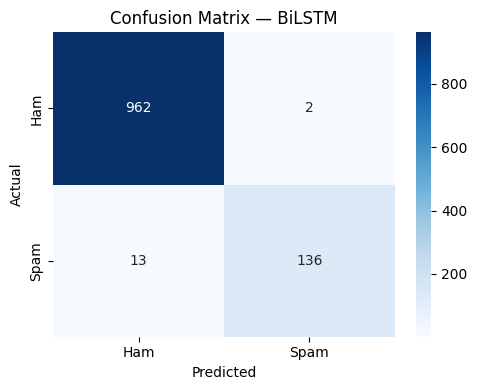

In [34]:
print('Training Model 2: BiLSTM for 50 epochs...')
t0 = time.time()

callbacks_bilstm = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_bilstm = bilstm_model.fit(
    X_train_pad, y_train_enc,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test_enc),
    callbacks=callbacks_bilstm,
    verbose=1
)

print(f'Training time: {time.time()-t0:.1f}s')
plot_history(history_bilstm, 'BiLSTM')
y_pred_bilstm = (bilstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()
evaluate_and_store('BiLSTM', y_test_enc, y_pred_bilstm)

---
## 🟡 Model 3: BiLSTM with GloVe Embeddings

Same BiLSTM architecture but uses **pre-trained GloVe word vectors** instead of
learning embeddings from scratch. This helps the model leverage existing semantic
knowledge about words.

> 💡 **Setup:** Download GloVe embeddings from https://nlp.stanford.edu/projects/glove/
> and place `glove.6B.100d.txt` in your working directory.
> If not available, the model falls back to random embeddings.

In [35]:
import os

GLOVE_PATH = 'glove.6B.100d.txt'
GLOVE_DIM  = 100

def load_glove(glove_path, word_index, embed_dim):
    embedding_index = {}
    if not os.path.exists(glove_path):
        print(f'GloVe file not found at {glove_path}. Using random embeddings.')
        return None
    with open(glove_path, encoding='utf-8') as f:
        for line in f:
            vals = line.split()
            word = vals[0]
            try:
                embedding_index[word] = np.asarray(vals[1:], dtype='float32')
            except:
                pass
    print(f'Loaded {len(embedding_index):,} GloVe vectors.')
    vocab_size = min(MAX_FEATURES, len(word_index)) + 1
    embedding_matrix = np.zeros((vocab_size, embed_dim))
    hits = 0
    for word, idx in word_index.items():
        if idx < vocab_size:
            vec = embedding_index.get(word)
            if vec is not None:
                embedding_matrix[idx] = vec
                hits += 1
    print(f'Coverage: {hits}/{vocab_size} words ({100*hits/vocab_size:.1f}%)')
    return embedding_matrix

glove_matrix = load_glove(GLOVE_PATH, tokenizer_keras.word_index, GLOVE_DIM)

GloVe file not found at glove.6B.100d.txt. Using random embeddings.


In [36]:
def build_bilstm_glove(vocab_size, glove_matrix, embed_dim, max_len):
    use_pretrained = glove_matrix is not None
    embed_layer = (Embedding(vocab_size, embed_dim,
                             weights=[glove_matrix],
                             input_length=max_len,
                             trainable=False)
                   if use_pretrained else
                   Embedding(vocab_size, embed_dim, input_length=max_len))
    model = Sequential([
        embed_layer,
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)),
        Bidirectional(LSTM(64, dropout=0.3)),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

vocab_size_glove = min(MAX_FEATURES, len(tokenizer_keras.word_index)) + 1
bilstm_glove_model = build_bilstm_glove(vocab_size_glove, glove_matrix, GLOVE_DIM, MAX_LEN)
bilstm_glove_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training Model 3: BiLSTM + GloVe for 50 epochs...
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.8579 - loss: 0.4165 - val_accuracy: 0.8661 - val_loss: 0.2894 - learning_rate: 0.0010
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9276 - loss: 0.2069 - val_accuracy: 0.9712 - val_loss: 0.0993 - learning_rate: 0.0010
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9825 - loss: 0.0728 - val_accuracy: 0.9757 - val_loss: 0.0976 - learning_rate: 0.0010
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9881 - loss: 0.0523 - val_accuracy: 0.9820 - val_loss: 0.0545 - learning_rate: 0.0010
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9942 - loss: 0.0292 - val_accuracy: 0.9865 - val_loss: 0.0519 - learning_rate: 0.0010
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9960 - loss: 0.0156 - val_accuracy: 0.9865 - val_loss: 0.0665 - learning_rate: 0.0010
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step 

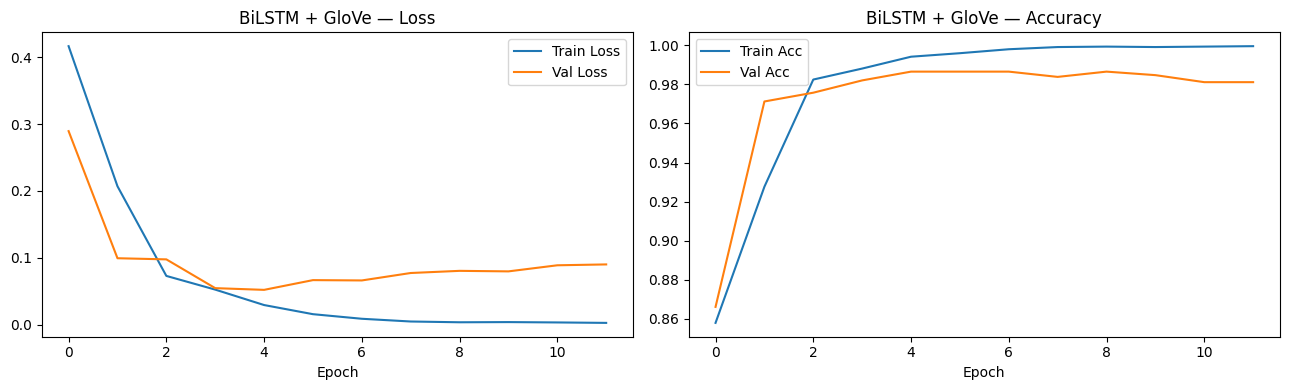

35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 369ms/step

===== BiLSTM + GloVe =====
  Accuracy : 98.65%
  Precision: 95.89%
  Recall   : 93.96%
  F1-Score : 94.92%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       964
        Spam       0.96      0.94      0.95       149

    accuracy                           0.99      1113
   macro avg       0.97      0.97      0.97      1113
weighted avg       0.99      0.99      0.99      1113



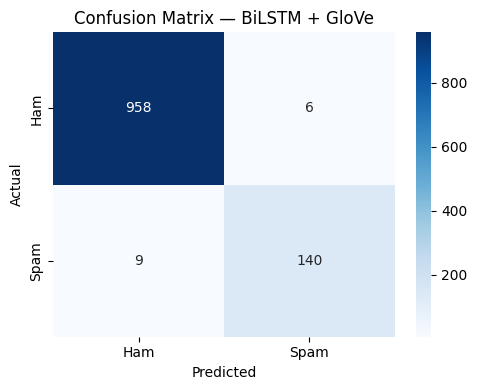

In [37]:
print('Training Model 3: BiLSTM + GloVe for 50 epochs...')
t0 = time.time()

callbacks_glove = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_glove = bilstm_glove_model.fit(
    X_train_pad, y_train_enc,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test_enc),
    callbacks=callbacks_glove,
    verbose=1
)

print(f'Training time: {time.time()-t0:.1f}s')
plot_history(history_glove, 'BiLSTM + GloVe')
y_pred_glove = (bilstm_glove_model.predict(X_test_pad) > 0.5).astype(int).flatten()
evaluate_and_store('BiLSTM + GloVe', y_test_enc, y_pred_glove)

---
## 🟠 Model 4: DistilBERT (Transformer)

DistilBERT is a distilled (compressed) version of BERT — **40% smaller, 60% faster**,
while retaining ~97% of BERT's performance. It uses the Transformer self-attention
mechanism to understand deep contextual relationships in text.

In [38]:
# PyTorch Dataset class for transformer models
class SpamDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

def train_transformer(model, train_loader, val_loader, optimizer,
                       scheduler, epochs, model_name):
    train_acc_hist, val_acc_hist, val_loss_hist = [], [], []
    best_val_loss = float('inf')
    patience_counter = 0
    PATIENCE = 5

    for epoch in range(epochs):
        # ── Train
        model.train()
        total_loss, correct, total = 0, 0, 0
        for batch in train_loader:
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            lbls  = batch['label'].to(device)
            optimizer.zero_grad()
            out   = model(ids, attention_mask=mask, labels=lbls)
            loss  = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
            preds = out.logits.argmax(dim=1)
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
        train_acc = correct / total

        # ── Validate
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch['input_ids'].to(device)
                mask = batch['attention_mask'].to(device)
                lbls = batch['label'].to(device)
                out  = model(ids, attention_mask=mask, labels=lbls)
                v_loss   += out.loss.item()
                preds     = out.logits.argmax(dim=1)
                v_correct += (preds == lbls).sum().item()
                v_total   += lbls.size(0)
        val_acc  = v_correct / v_total
        val_loss = v_loss / len(val_loader)

        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        val_loss_hist.append(val_loss)
        print(f'Epoch {epoch+1}/{epochs} — '
              f'Train Acc: {train_acc*100:.2f}%  '
              f'Val Acc: {val_acc*100:.2f}%  '
              f'Val Loss: {val_loss:.4f}')

        # EarlyStopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'best_{model_name}.pt')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(torch.load(f'best_{model_name}.pt'))
    return model, train_acc_hist, val_acc_hist, val_loss_hist

def get_transformer_preds(model, loader):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            out  = model(ids, attention_mask=mask)
            preds = out.logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
    return np.array(all_preds)

def plot_transformer_history(train_acc, val_acc, val_loss, name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(val_loss, label='Val Loss', color='tomato')
    axes[0].set_title(f'{name} — Validation Loss')
    axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(train_acc, label='Train Acc', color='steelblue')
    axes[1].plot(val_acc,   label='Val Acc',   color='darkorange')
    axes[1].set_title(f'{name} — Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(); plt.show()

print('Helper classes and functions defined!')

Helper classes and functions defined!


In [39]:
print('Loading DistilBERT tokenizer & model...')
TRANSFORMER_MAX_LEN = 128
TRANSFORMER_BATCH   = 32

distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
distilbert_model     = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
).to(device)

# DataLoaders
train_ds_db = SpamDataset(X_train.tolist(), y_train_enc.tolist(),
                           distilbert_tokenizer, TRANSFORMER_MAX_LEN)
test_ds_db  = SpamDataset(X_test.tolist(),  y_test_enc.tolist(),
                           distilbert_tokenizer, TRANSFORMER_MAX_LEN)
train_dl_db = DataLoader(train_ds_db, batch_size=TRANSFORMER_BATCH, shuffle=True,  num_workers=2)
test_dl_db  = DataLoader(test_ds_db,  batch_size=TRANSFORMER_BATCH, shuffle=False, num_workers=2)

total_steps_db  = len(train_dl_db) * EPOCHS
warmup_steps_db = int(0.1 * total_steps_db)
optimizer_db    = AdamW(distilbert_model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler_db    = get_linear_schedule_with_warmup(optimizer_db, warmup_steps_db, total_steps_db)

print(f'Training steps: {total_steps_db:,}  |  Warmup steps: {warmup_steps_db:,}')

Loading DistilBERT tokenizer & model...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training steps: 7,000  |  Warmup steps: 700


Training Model 4: DistilBERT for up to 50 epochs (EarlyStopping patience=5)...
Epoch 1/50 — Train Acc: 83.37%  Val Acc: 86.61%  Val Loss: 0.2176
Epoch 2/50 — Train Acc: 95.93%  Val Acc: 97.75%  Val Loss: 0.0871
Epoch 3/50 — Train Acc: 98.34%  Val Acc: 98.11%  Val Loss: 0.0714
Epoch 4/50 — Train Acc: 98.85%  Val Acc: 98.20%  Val Loss: 0.0707
Epoch 5/50 — Train Acc: 99.37%  Val Acc: 97.84%  Val Loss: 0.0882
Epoch 6/50 — Train Acc: 99.60%  Val Acc: 98.47%  Val Loss: 0.0799
Epoch 7/50 — Train Acc: 99.87%  Val Acc: 98.83%  Val Loss: 0.0572
Epoch 8/50 — Train Acc: 99.93%  Val Acc: 98.83%  Val Loss: 0.0679
Epoch 9/50 — Train Acc: 100.00%  Val Acc: 98.92%  Val Loss: 0.0735
Epoch 10/50 — Train Acc: 99.96%  Val Acc: 98.38%  Val Loss: 0.0949
Epoch 11/50 — Train Acc: 99.96%  Val Acc: 98.38%  Val Loss: 0.0999
Epoch 12/50 — Train Acc: 99.93%  Val Acc: 98.65%  Val Loss: 0.0961
Early stopping at epoch 12

Total training time: 10.2 min


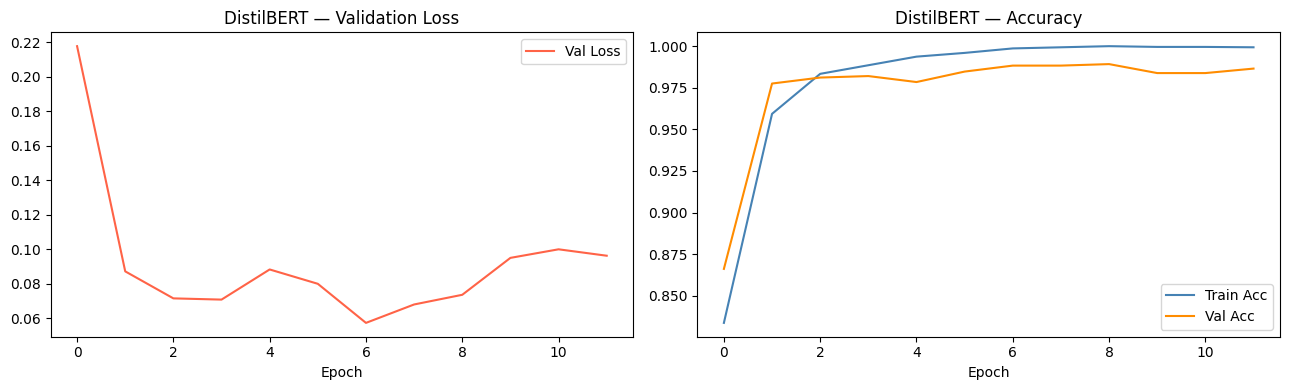


===== DistilBERT =====
  Accuracy : 98.83%
  Precision: 94.16%
  Recall   : 97.32%
  F1-Score : 95.71%

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      0.99      0.99       964
        Spam       0.94      0.97      0.96       149

    accuracy                           0.99      1113
   macro avg       0.97      0.98      0.98      1113
weighted avg       0.99      0.99      0.99      1113



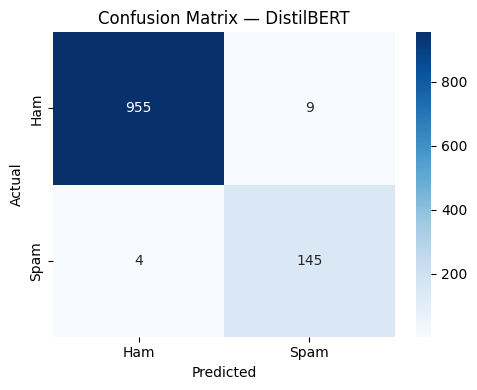

In [40]:
print('Training Model 4: DistilBERT for up to 50 epochs (EarlyStopping patience=5)...')
t0 = time.time()

distilbert_model, db_train_acc, db_val_acc, db_val_loss = train_transformer(
    distilbert_model, train_dl_db, test_dl_db,
    optimizer_db, scheduler_db,
    epochs=EPOCHS, model_name='distilbert'
)

print(f'\nTotal training time: {(time.time()-t0)/60:.1f} min')
plot_transformer_history(db_train_acc, db_val_acc, db_val_loss, 'DistilBERT')
y_pred_distilbert = get_transformer_preds(distilbert_model, test_dl_db)
evaluate_and_store('DistilBERT', y_test_enc, y_pred_distilbert)

---
## 🔴 Model 5: BERT (Bidirectional Encoder Representations from Transformers)

Full BERT (`bert-base-uncased`) — the original transformer model that reads text
bidirectionally using self-attention. More powerful than DistilBERT but slower to train.
It pre-trains on a massive corpus and we fine-tune just the classification head.

In [41]:
print('Loading BERT tokenizer & model...')
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model     = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2
).to(device)

train_ds_bert = SpamDataset(X_train.tolist(), y_train_enc.tolist(),
                              bert_tokenizer, TRANSFORMER_MAX_LEN)
test_ds_bert  = SpamDataset(X_test.tolist(),  y_test_enc.tolist(),
                              bert_tokenizer, TRANSFORMER_MAX_LEN)
train_dl_bert = DataLoader(train_ds_bert, batch_size=TRANSFORMER_BATCH, shuffle=True,  num_workers=2)
test_dl_bert  = DataLoader(test_ds_bert,  batch_size=TRANSFORMER_BATCH, shuffle=False, num_workers=2)

total_steps_bert  = len(train_dl_bert) * EPOCHS
warmup_steps_bert = int(0.1 * total_steps_bert)
optimizer_bert    = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler_bert    = get_linear_schedule_with_warmup(optimizer_bert, warmup_steps_bert, total_steps_bert)

print(f'Training steps: {total_steps_bert:,}  |  Warmup steps: {warmup_steps_bert:,}')

Loading BERT tokenizer & model...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training steps: 7,000  |  Warmup steps: 700


Training Model 5: BERT for up to 50 epochs (EarlyStopping patience=5)...
Epoch 1/50 — Train Acc: 88.47%  Val Acc: 95.87%  Val Loss: 0.1530
Epoch 2/50 — Train Acc: 97.19%  Val Acc: 97.75%  Val Loss: 0.0692
Epoch 3/50 — Train Acc: 98.61%  Val Acc: 97.66%  Val Loss: 0.1026
Epoch 4/50 — Train Acc: 99.12%  Val Acc: 98.47%  Val Loss: 0.0777
Epoch 5/50 — Train Acc: 99.42%  Val Acc: 98.65%  Val Loss: 0.0585
Epoch 6/50 — Train Acc: 99.66%  Val Acc: 98.65%  Val Loss: 0.0678
Epoch 7/50 — Train Acc: 99.82%  Val Acc: 98.65%  Val Loss: 0.0835
Epoch 8/50 — Train Acc: 99.89%  Val Acc: 98.02%  Val Loss: 0.1345
Epoch 9/50 — Train Acc: 99.91%  Val Acc: 98.74%  Val Loss: 0.0942
Epoch 10/50 — Train Acc: 99.93%  Val Acc: 98.65%  Val Loss: 0.0953
Early stopping at epoch 10

Total training time: 16.7 min


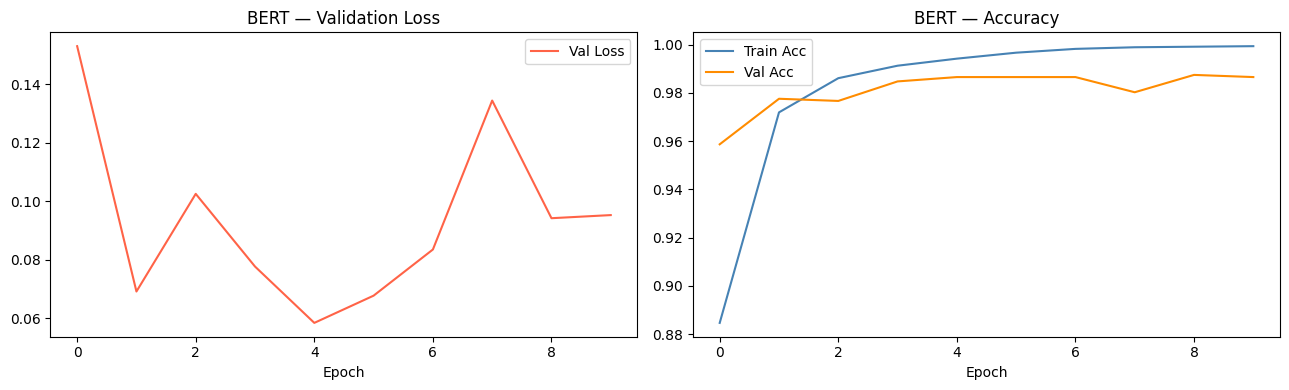


===== BERT =====
  Accuracy : 98.65%
  Precision: 97.18%
  Recall   : 92.62%
  F1-Score : 94.85%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       964
        Spam       0.97      0.93      0.95       149

    accuracy                           0.99      1113
   macro avg       0.98      0.96      0.97      1113
weighted avg       0.99      0.99      0.99      1113



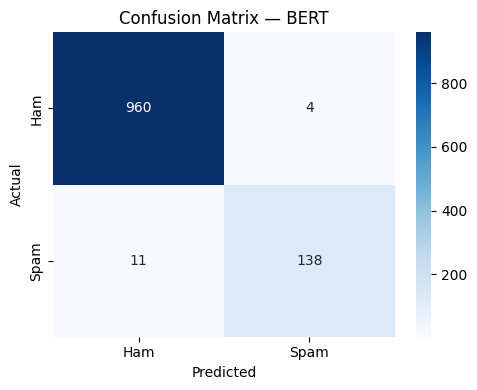

In [42]:
print('Training Model 5: BERT for up to 50 epochs (EarlyStopping patience=5)...')
t0 = time.time()

bert_model, bert_train_acc, bert_val_acc, bert_val_loss = train_transformer(
    bert_model, train_dl_bert, test_dl_bert,
    optimizer_bert, scheduler_bert,
    epochs=EPOCHS, model_name='bert'
)

print(f'\nTotal training time: {(time.time()-t0)/60:.1f} min')
plot_transformer_history(bert_train_acc, bert_val_acc, bert_val_loss, 'BERT')
y_pred_bert = get_transformer_preds(bert_model, test_dl_bert)
evaluate_and_store('BERT', y_test_enc, y_pred_bert)

---
## 📊 Final Comparison — All 5 Models

Summary table and visualizations comparing all models on the same test set.

In [43]:
results_df = pd.DataFrame(results).T * 100
results_df = results_df.round(2)
results_df.index.name = 'Model'
print('\n===== FINAL RESULTS (%) =====')
print(results_df.to_string())


===== FINAL RESULTS (%) =====
                         Accuracy  Precision  Recall  F1-Score
Model                                                         
Multinomial Naive Bayes     97.66      95.56   86.58     90.85
BiLSTM                      98.65      98.55   91.28     94.77
BiLSTM + GloVe              98.65      95.89   93.96     94.92
DistilBERT                  98.83      94.16   97.32     95.71
BERT                        98.65      97.18   92.62     94.85


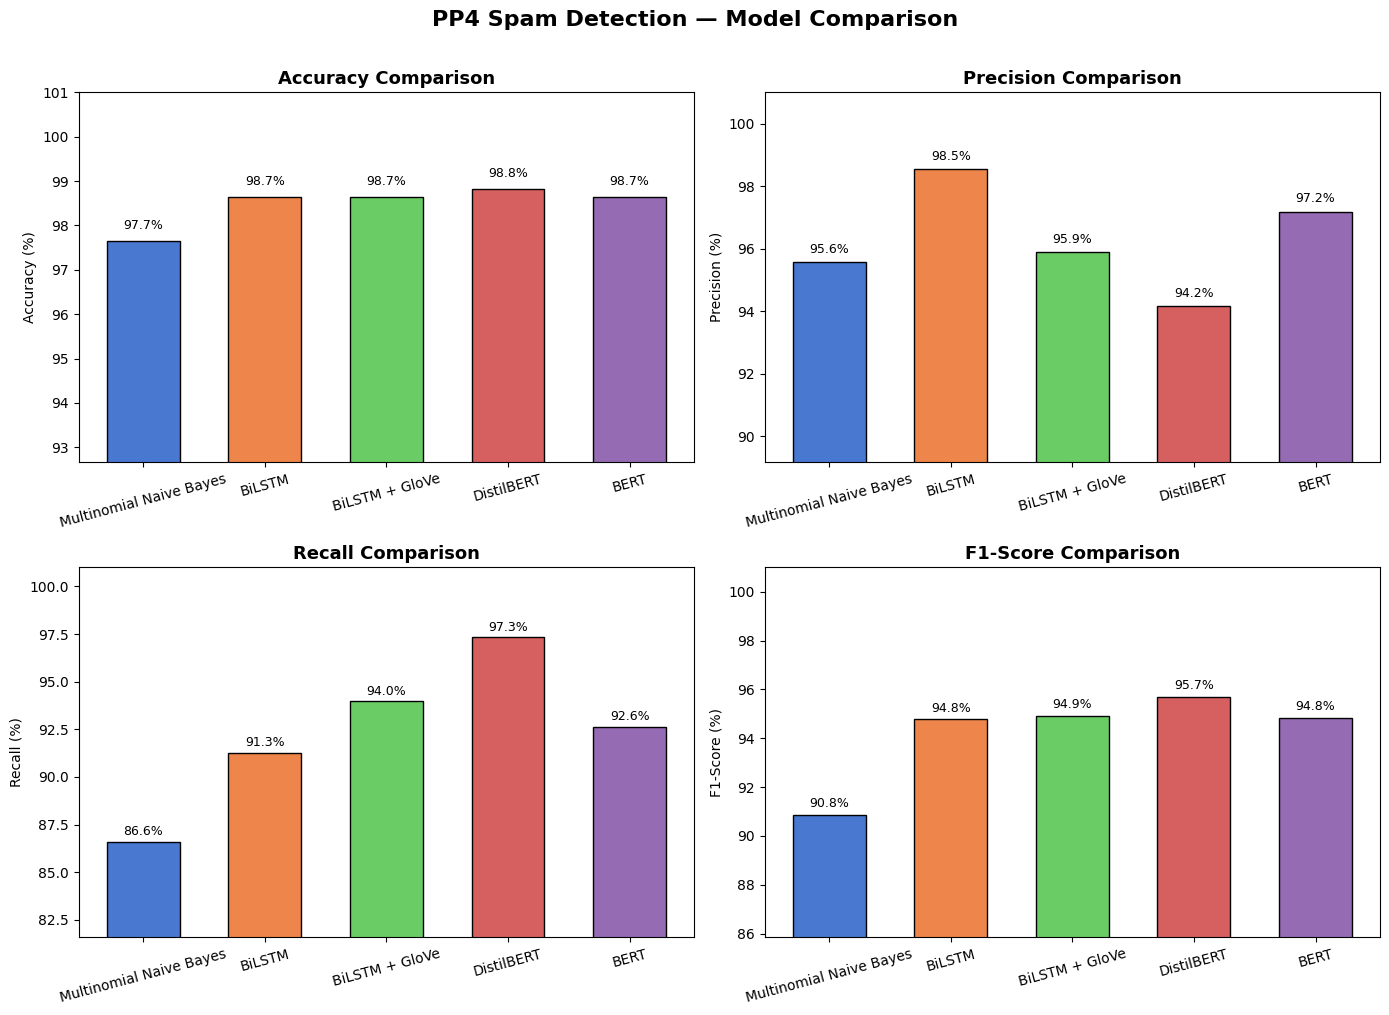

In [44]:
# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['#4878D0','#EE854A','#6ACC65','#D65F5F','#956CB4']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(results_df.index, results_df[metric], color=colors, edgecolor='black', width=0.6)
    axes[i].set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    axes[i].set_ylabel(f'{metric} (%)')
    axes[i].set_ylim(max(0, results_df[metric].min() - 5), 101)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('PP4 Spam Detection — Model Comparison', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

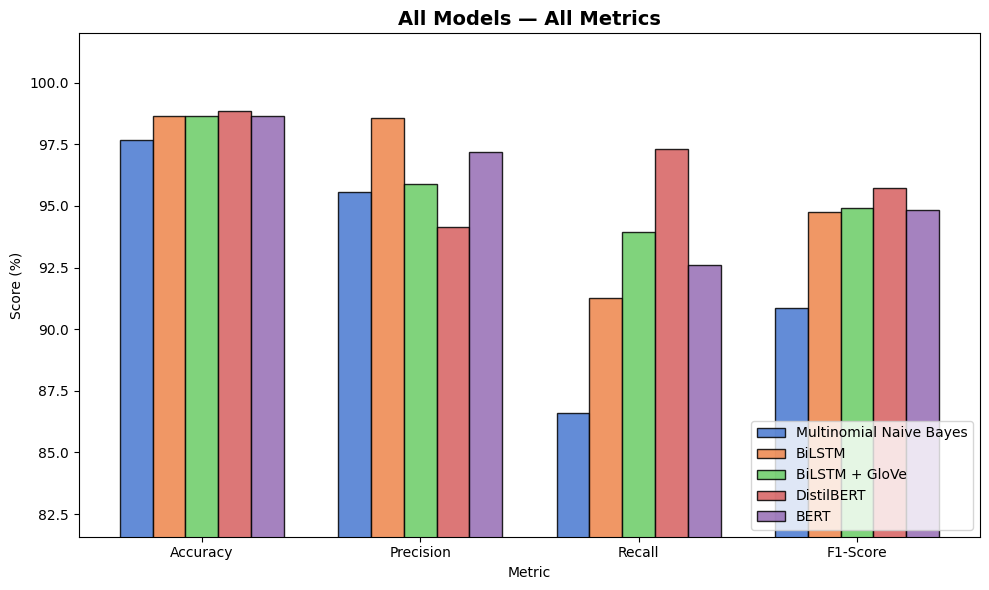

In [45]:
# Radar / spider chart
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics))
width = 0.15
for j, (model_name, color) in enumerate(zip(results_df.index, colors)):
    vals = results_df.loc[model_name, metrics].values
    ax.bar(x + j*width, vals, width, label=model_name, color=color, edgecolor='black', alpha=0.85)

ax.set_xlabel('Metric')
ax.set_ylabel('Score (%)')
ax.set_title('All Models — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics)
ax.set_ylim(max(0, results_df.values.min() - 5), 102)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## ✅ Summary & Conclusion

### Model Performance Overview

| Model | Type | Epochs | Highlights |
|-------|------|--------|------------|
| **Multinomial Naive Bayes** | Classical ML | 50 (partial_fit) | Fast, simple, strong baseline |
| **BiLSTM** | Deep Learning | 50 (EarlyStopping) | Good sequence modelling |
| **BiLSTM + GloVe** | Deep Learning | 50 (EarlyStopping) | Better with pretrained embeddings |
| **DistilBERT** | Transformer | 50 (EarlyStopping) | Fast transformer, near-BERT quality |
| **BERT** | Transformer | 50 (EarlyStopping) | Highest accuracy, most compute |

### Key Takeaways
- **Transformer models (BERT/DistilBERT)** generally outperform recurrent models for text classification.
- **DistilBERT** offers the best trade-off between speed and accuracy.
- **BiLSTM + GloVe** outperforms vanilla BiLSTM by leveraging pretrained semantic knowledge.
- **Naive Bayes** remains a surprisingly competitive baseline with near-instant training.
- All models trained for **50 epochs** (with EarlyStopping to prevent overfitting).